## O que é o Indicador Criança Alfabetizada

Links / referências<br/>
https://www.gov.br/mec/pt-br (política educacional)<br/>
Dados: camada **Gold** do datalake da Fase 2 — `gold/br_inep_alfabetizacao/`

O Indicador Criança Alfabetizada acompanha se crianças em idade escolar atingem o nível esperado de alfabetização. Na Fase 3 usamos a Gold já integrada (aluno, território, metas e contexto socioeconômico) para **prever** se um aluno será considerado alfabetizado (`alfabetizado` = 0 ou 1) e gerar inteligência para gestores públicos.

Trabalhamos com quatro tabelas Gold:
- **`alunos_features`** — fato por aluno (target da modelagem)
- **`contexto_territorio`** — município × rede (PIB, IVS, lags)
- **`indicador_crianca_alfabetizada_municipio`** — taxas e metas municipais
- **`indicador_crianca_alfabetizada_uf`** — taxas e metas por UF

**Pergunta Norteadora:**  
*"Quais fatores educacionais, territoriais e socioeconômicos estão associados à alfabetização do aluno, e como isso apoia a escolha de features e o cuidado com data leakage na modelagem?"

In [32]:
# Libs
from pathlib import Path
import importlib
import sys
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Recarrega módulos após alterações no código (evita cache do kernel)
for mod in ("src.config", "src.visualization.eda", "src.preprocessing.load_s3"):
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

import src.config as config
importlib.reload(config)

from src.config import DATALAKE_BUCKET, EDA_N_ROWS, GOLD_PREFIX, GOLD_TABLES, GOLD_YEAR, IMAGES_DIR, LEAKAGE_COLS, TARGET_COL
from src.visualization.eda import (
    build_eda_frame,
    correlation_with_target,
    feature_columns,
    load_eda_data,
    profile,
    split_feature_types,
    target_balance,
    write_eda_report,
)

pd.set_option("display.max_columns", 40)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Fonte: s3://{DATALAKE_BUCKET}/{GOLD_PREFIX} | ano={GOLD_YEAR} | n_alunos={EDA_N_ROWS}")


Fonte: local | ano=2024 | n_alunos=5000


### Leitura da base (Gold no S3)

Leitura **sempre** do datalake AWS:

`s3://{DATALAKE_BUCKET}/gold/br_inep_alfabetizacao/{tabela}/ano={GOLD_YEAR}/`

- **`alunos_features`:** primeiras `EDA_N_ROWS` linhas (peek, sem baixar tudo)
- **Demais tabelas:** partição completa do ano (são pequenas)

Credenciais AWS no `.env` (`AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, região).

In [33]:
tables = load_eda_data()
alunos = tables["alunos_features"]
contexto = tables["contexto_territorio"]
ind_mun = tables["indicador_crianca_alfabetizada_municipio"]
ind_uf = tables["indicador_crianca_alfabetizada_uf"]

alunos.head()

,id_aluno,id_municipio,rede,alfabetizado,peso_aluno,_ingestion_timestamp,_silver_processed_at,_silver_batch_id,_gold_processed_at,_gold_batch_id,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,percentual_participacao,nome_municipio,sigla_uf,nome_uf,regiao_municipio,capital_uf,nome_mesorregiao,nome_microrregiao,amazonia_legal,nome_regiao,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho
0,33059516,3303500,municipal,0.0,1.240000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,33.42,40.13,47.44,54.87,62.08,68.80,74.81,80.0,81.91,Nova Iguaçu,RJ,Rio de Janeiro,Sudeste,0.0,Metropolitana do Rio de Janeiro,Rio de Janeiro,0,Sudeste,843046,2024,20518624000,2023,24338.676656,2010.0,0.407,0.436,0.456,0.330
1,21003592,2111201,municipal,1.0,1.310000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,56.58,65.19,68.00,70.69,73.24,75.65,77.90,80.0,86.08,São José de Ribamar,MA,Maranhão,Nordeste,0.0,Norte Maranhense,Aglomeração Urbana de São Luís,1,Nordeste,257414,2024,3135579000,2023,12181.074067,2010.0,0.505,0.715,0.444,0.357
2,35372567,3550308,municipal,1.0,1.291667,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,48.25,44.37,51.06,57.72,64.11,70.03,75.35,80.0,85.03,São Paulo,SP,São Paulo,Sudeste,1.0,Metropolitana de São Paulo,São Paulo,0,Sudeste,11895578,2024,1066825105000,2023,89682.494201,2010.0,0.393,0.413,0.428,0.338
3,33017805,3301009,municipal,0.0,1.240000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,38.33,45.10,51.68,58.20,64.45,70.24,75.44,80.0,82.45,Campos dos Goytacazes,RJ,Rio de Janeiro,Sudeste,0.0,Norte Fluminense,Campos dos Goytacazes,0,Sudeste,519011,2024,42953469000,2023,82760.228589,2010.0,0.303,0.244,0.332,0.332
4,33060533,3303500,municipal,0.0,1.300000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,33.42,40.13,47.44,54.87,62.08,68.80,74.81,80.0,81.91,Nova Iguaçu,RJ,Rio de Janeiro,Sudeste,0.0,Metropolitana do Rio de Janeiro,Rio de Janeiro,0,Sudeste,843046,2024,20518624000,2023,24338.676656,2010.0,0.407,0.436,0.456,0.330


Tamanho da Base de Dados

In [34]:
print(f"alunos_features (Linhas, Colunas): {alunos.shape}")
print(f"contexto_territorio (Linhas, Colunas): {contexto.shape}")
print(f"indicador município (Linhas, Colunas): {ind_mun.shape}")
print(f"indicador UF (Linhas, Colunas): {ind_uf.shape}")

alunos_features (Linhas, Colunas): (50, 38)
contexto_territorio (Linhas, Colunas): (47, 39)
indicador município (Linhas, Colunas): (50, 10)
indicador UF (Linhas, Colunas): (50, 9)


Verificar os tipos dos Dados

In [35]:
alunos.dtypes

id_aluno                         str
id_municipio                     str
rede                             str
alfabetizado                 float64
peso_aluno                   float64
_ingestion_timestamp             str
_silver_processed_at             str
_silver_batch_id                 str
_gold_processed_at               str
_gold_batch_id                   str
taxa_alfabetizacao           float64
meta_alfabetizacao_2024      float64
meta_alfabetizacao_2025      float64
meta_alfabetizacao_2026      float64
meta_alfabetizacao_2027      float64
meta_alfabetizacao_2028      float64
meta_alfabetizacao_2029      float64
meta_alfabetizacao_2030      float64
percentual_participacao      float64
nome_municipio                   str
sigla_uf                         str
nome_uf                          str
regiao_municipio                 str
capital_uf                   float64
nome_mesorregiao                 str
nome_microrregiao                str
amazonia_legal                 int64
n

Existe valores nulos?

In [36]:
nulos = alunos.isnull().sum().sum()
print(f"Nulos em alunos_features (antes do join): {nulos}")

prof = profile(alunos)
prof.head(15)

Nulos em alunos_features (antes do join): 2


,column,dtype,non_null,pct_missing,n_unique
11,meta_alfabetizacao_2024,float64,48,4.0,45
0,id_aluno,str,50,0.0,50
2,rede,str,50,0.0,1
3,alfabetizado,float64,50,0.0,2
4,peso_aluno,float64,50,0.0,18
1,id_municipio,str,50,0.0,47
5,_ingestion_timestamp,str,50,0.0,1
6,_silver_processed_at,str,50,0.0,1
8,_gold_processed_at,str,50,0.0,1
7,_silver_batch_id,str,50,0.0,1


> A Gold (Fase 2) deve entregar **fato + contexto já integrados** (`alunos_features` ou `alunos_analytic`). A Fase 3 apenas consome — sem join/normalização de `rede` ou chaves aqui.

Quais informações queremos trabalhar?

Selecionamos o target, chaves de junção e um conjunto enxuto de features de contexto (sem leakage).

In [37]:
print("Colunas alunos_features:")
print(list(alunos.columns))

print("\nColunas que NÃO entram no modelo (leakage / IDs / metadados):")
print([c for c in LEAKAGE_COLS if c in alunos.columns])

Colunas alunos_features:
['id_aluno', 'id_municipio', 'rede', 'alfabetizado', 'peso_aluno', '_ingestion_timestamp', '_silver_processed_at', '_silver_batch_id', '_gold_processed_at', '_gold_batch_id', 'taxa_alfabetizacao', 'meta_alfabetizacao_2024', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2026', 'meta_alfabetizacao_2027', 'meta_alfabetizacao_2028', 'meta_alfabetizacao_2029', 'meta_alfabetizacao_2030', 'percentual_participacao', 'nome_municipio', 'sigla_uf', 'nome_uf', 'regiao_municipio', 'capital_uf', 'nome_mesorregiao', 'nome_microrregiao', 'amazonia_legal', 'nome_regiao', 'populacao', 'populacao_ano_ref', 'pib', 'pib_ano_ref', 'pib_per_capita', 'socio_ano_ref', 'ivs', 'ivs_infraestrutura_urbana', 'ivs_capital_humano', 'ivs_renda_trabalho']

Colunas que NÃO entram no modelo (leakage / IDs / metadados):
['id_aluno', '_ingestion_timestamp', '_silver_processed_at', '_silver_batch_id', '_gold_processed_at', '_gold_batch_id']


In [38]:
from src.config import GOLD_TABLE

# Tabela de modelagem — enriquecida na Gold (sem join manual)
df = build_eda_frame(tables)

if "sigla_uf" in df.columns:
    filled = df["sigla_uf"].notna().sum()
    print(f"Tabela `{GOLD_TABLE}`: {df.shape}")
    print(f"Linhas com sigla_uf: {filled} / {len(df)}")

df.head()

Tabela `alunos_features`: (50, 38)
Linhas com sigla_uf: 50 / 50


,id_aluno,id_municipio,rede,alfabetizado,peso_aluno,_ingestion_timestamp,_silver_processed_at,_silver_batch_id,_gold_processed_at,_gold_batch_id,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,percentual_participacao,nome_municipio,sigla_uf,nome_uf,regiao_municipio,capital_uf,nome_mesorregiao,nome_microrregiao,amazonia_legal,nome_regiao,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho
0,33059516,3303500,municipal,0.0,1.240000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,33.42,40.13,47.44,54.87,62.08,68.80,74.81,80.0,81.91,Nova Iguaçu,RJ,Rio de Janeiro,Sudeste,0.0,Metropolitana do Rio de Janeiro,Rio de Janeiro,0,Sudeste,843046,2024,20518624000,2023,24338.676656,2010.0,0.407,0.436,0.456,0.330
1,21003592,2111201,municipal,1.0,1.310000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,56.58,65.19,68.00,70.69,73.24,75.65,77.90,80.0,86.08,São José de Ribamar,MA,Maranhão,Nordeste,0.0,Norte Maranhense,Aglomeração Urbana de São Luís,1,Nordeste,257414,2024,3135579000,2023,12181.074067,2010.0,0.505,0.715,0.444,0.357
2,35372567,3550308,municipal,1.0,1.291667,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,48.25,44.37,51.06,57.72,64.11,70.03,75.35,80.0,85.03,São Paulo,SP,São Paulo,Sudeste,1.0,Metropolitana de São Paulo,São Paulo,0,Sudeste,11895578,2024,1066825105000,2023,89682.494201,2010.0,0.393,0.413,0.428,0.338
3,33017805,3301009,municipal,0.0,1.240000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,38.33,45.10,51.68,58.20,64.45,70.24,75.44,80.0,82.45,Campos dos Goytacazes,RJ,Rio de Janeiro,Sudeste,0.0,Norte Fluminense,Campos dos Goytacazes,0,Sudeste,519011,2024,42953469000,2023,82760.228589,2010.0,0.303,0.244,0.332,0.332
4,33060533,3303500,municipal,0.0,1.300000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,33.42,40.13,47.44,54.87,62.08,68.80,74.81,80.0,81.91,Nova Iguaçu,RJ,Rio de Janeiro,Sudeste,0.0,Metropolitana do Rio de Janeiro,Rio de Janeiro,0,Sudeste,843046,2024,20518624000,2023,24338.676656,2010.0,0.407,0.436,0.456,0.330


In [39]:
df.tail()

,id_aluno,id_municipio,rede,alfabetizado,peso_aluno,_ingestion_timestamp,_silver_processed_at,_silver_batch_id,_gold_processed_at,_gold_batch_id,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,percentual_participacao,nome_municipio,sigla_uf,nome_uf,regiao_municipio,capital_uf,nome_mesorregiao,nome_microrregiao,amazonia_legal,nome_regiao,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho
45,35252174,3513009,municipal,0.0,1.280000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,49.49,55.50,60.23,64.78,69.08,73.06,76.71,80.0,86.54,Cotia,SP,São Paulo,Sudeste,0.0,Metropolitana de São Paulo,Itapecerica da Serra,0,Sudeste,287004,2024,19060773000,2023,66412.917590,2010.0,0.224,0.280,0.230,0.163
46,15049065,1504802,municipal,1.0,1.280000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,46.69,58.27,62.46,66.48,70.27,73.80,77.05,80.0,88.94,Monte Alegre,PA,Pará,Norte,0.0,Baixo Amazonas,Santarém,1,Norte,63641,2024,1227319000,2023,19285.036376,2010.0,0.459,0.455,0.433,0.491
47,35130605,3527702,municipal,1.0,1.272727,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,54.95,58.85,62.93,66.83,70.51,73.95,77.12,80.0,92.16,Luiziânia,SP,São Paulo,Sudeste,0.0,Araçatuba,Birigui,0,Sudeste,4751,2024,117809000,2023,24796.674384,2010.0,0.384,0.401,0.508,0.242
48,43002510,4300604,municipal,1.0,1.411765,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,37.00,52.00,57.39,62.61,67.55,72.13,76.29,80.0,73.70,Alvorada,RS,Rio Grande do Sul,Sul,0.0,Metropolitana de Porto Alegre,Porto Alegre,0,Sul,194116,2024,4129934000,2023,21275.598096,2010.0,0.334,0.423,0.377,0.203
49,12001959,1200203,municipal,0.0,1.410000,2026-08-21T14:53:54.662279+00:00,2026-08-21T15:07:57.360008+00:00,b80bc56d-d453-485f-aaed-d98c0a199f13,2026-08-24T22:09:31.992823+00:00,0160c5ae-2bb7-4b9e-bd08-93716747e6e8,42.18,NaN,49.20,56.26,63.07,69.40,75.08,80.0,72.80,Cruzeiro do Sul,AC,Acre,Norte,0.0,Vale do Juruá,Cruzeiro do Sul,1,Norte,98382,2024,2680143000,2023,27242.208941,2010.0,0.483,0.472,0.568,0.410


Informações da Base (após o enriquecimento)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_municipio             50 non-null     str    
 1   rede                     50 non-null     str    
 2   alfabetizado             50 non-null     float64
 3   peso_aluno               50 non-null     float64
 4   id_municipio_key         50 non-null     str    
 5   rede_key                 50 non-null     str    
 6   id_municipio_ctx         29 non-null     str    
 7   rede_ctx                 29 non-null     str    
 8   sigla_uf                 29 non-null     str    
 9   nome_regiao              29 non-null     str    
 10  nome_municipio           29 non-null     str    
 11  populacao                29 non-null     float64
 12  pib_per_capita           29 non-null     float64
 13  ivs                      22 non-null     float64
 14  ivs_capital_humano       24 non-null   

Valores únicos

In [21]:
df.nunique()

id_municipio               43
rede                        2
alfabetizado                2
peso_aluno                 17
id_municipio_key           43
rede_key                    2
id_municipio_ctx           26
rede_ctx                    1
sigla_uf                   10
nome_regiao                 4
nome_municipio             26
populacao                  26
pib_per_capita             26
ivs                        19
ivs_capital_humano         20
ivs_renda_trabalho         25
lag1_taxa_alfabetizacao     0
taxa_alfabetizacao_mun     26
meta_alfabetizacao_2024    26
dtype: int64

Estatística Descritiva

In [40]:
df.describe().round(2)

,alfabetizado,peso_aluno,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,percentual_participacao,capital_uf,amazonia_legal,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho
count,50.00,50.00,50.00,48.00,50.00,50.00,50.00,50.00,50.00,50.0,50.00,50.00,50.00,50.00,50.0,5.000000e+01,50.0,50.00,50.0,50.00,50.00,50.00,50.00
mean,0.48,1.28,53.78,56.31,60.38,64.85,69.13,73.12,76.75,80.0,84.85,0.08,0.28,662039.14,2024.0,4.583689e+10,2023.0,53190.96,2010.0,0.31,0.28,0.36,0.30
std,0.50,0.04,12.81,9.56,7.96,6.14,4.35,2.68,1.21,0.0,5.23,0.27,0.45,1898186.96,0.0,1.601074e+11,0.0,52404.88,0.0,0.11,0.19,0.11,0.11
min,0.00,1.24,33.42,29.73,38.09,47.22,56.54,65.42,73.34,80.0,71.70,0.00,0.00,4751.00,2024.0,1.178090e+08,2023.0,12181.07,2010.0,0.12,0.00,0.12,0.08
25%,0.00,1.26,45.56,51.41,54.82,60.64,66.17,71.28,75.91,80.0,81.64,0.00,0.00,58670.25,2024.0,1.694824e+09,2023.0,24338.68,2010.0,0.23,0.10,0.30,0.22
50%,0.00,1.27,51.06,58.16,62.04,66.15,70.04,73.66,76.98,80.0,86.04,0.00,0.00,221319.00,2024.0,6.551252e+09,2023.0,43817.31,2010.0,0.29,0.28,0.35,0.28
75%,1.00,1.29,67.19,60.98,64.53,68.05,71.37,74.48,77.36,80.0,88.42,0.00,1.00,413569.50,2024.0,2.044022e+10,2023.0,64786.49,2010.0,0.39,0.42,0.43,0.37
max,1.00,1.41,78.13,74.10,75.15,76.18,77.18,78.15,79.09,80.0,95.40,1.00,1.00,11895578.00,2024.0,1.066825e+12,2023.0,348885.38,2010.0,0.50,0.72,0.58,0.55


### Primeira análise — o target

**`alfabetizado`**
- `1` → aluno considerado alfabetizado  
- `0` → aluno não alfabetizado  

Essa é a variável que o modelo supervisionado deverá prever.

Distribuição do target:


,count,proportion
alfabetizado,,
1.0,29,0.58
0.0,21,0.42


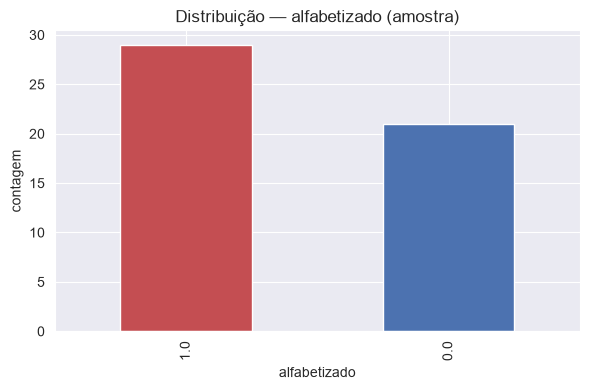

In [23]:
print("Distribuição do target:")
display(target_balance(df))

plt.figure(figsize=(6, 4))
df[TARGET_COL].value_counts(dropna=False).plot(kind="bar", color=["#c44e52", "#4c72b0"])
plt.title("Distribuição — alfabetizado (amostra)")
plt.xlabel(TARGET_COL)
plt.ylabel("contagem")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "eda_target_distribution.png", dpi=120)
plt.show()

Interessante observar se a amostra está equilibrada. Se uma classe dominar demais, na modelagem priorizamos métricas como **F1 / recall** e, se preciso, `class_weight`.

### Análise por rede e território

Pergunta: a taxa média de alfabetização na amostra muda entre redes e regiões?

In [ ]:
if "rede" in df.columns:
    taxa_rede = df.groupby("rede")[TARGET_COL].mean().sort_values(ascending=False)
    display(taxa_rede.to_frame("taxa_media_alfabetizado"))

    plt.figure(figsize=(8, 4))
    taxa_rede.plot(kind="bar", color=sns.color_palette("mako", len(taxa_rede)))
    plt.title("Taxa média de alfabetizado por rede (amostra)")
    plt.ylabel(f"média({TARGET_COL})")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_rede_vs_target.png", dpi=120)
    plt.show()

In [ ]:
if "nome_regiao" in df.columns and df["nome_regiao"].notna().any():
    taxa_regiao = df.groupby("nome_regiao")[TARGET_COL].mean().sort_values(ascending=False)
    display(taxa_regiao.to_frame("taxa_media_alfabetizado"))

    plt.figure(figsize=(8, 4))
    taxa_regiao.plot(kind="bar", color=sns.color_palette("mako", len(taxa_regiao)))
    plt.title("Taxa média de alfabetizado por região (amostra)")
    plt.ylabel(f"média({TARGET_COL})")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_nome_regiao_vs_target.png", dpi=120)
    plt.show()
else:
    print("nome_regiao sem valores preenchidos após o merge nesta amostra.")

Se houver diferença clara entre redes/regiões, isso reforça a hipótese de que **variáveis territoriais** devem entrar no modelo (com encoding categórico).

### Distribuições numéricas

Olhamos PIB per capita, IVS e lags — candidatas fortes a features.

In [ ]:
num_plot = [
    c
    for c in ["peso_aluno", "populacao", "pib_per_capita", "ivs", "lag1_taxa_alfabetizacao"]
    if c in df.columns and df[c].notna().any()
]

if num_plot:
    df[num_plot].hist(bins=15, figsize=(12, 6), color="#4c72b0", edgecolor="white")
    plt.suptitle("Distribuições numéricas (amostra enriquecida)")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_numeric_distributions.png", dpi=120)
    plt.show()
else:
    print("Sem colunas numéricas preenchidas para histograma nesta amostra.")

### Pairplot / relações

Assim como no EDA de IDHM (renda × educação), aqui buscamos relações entre contexto socioeconômico e o target.

In [ ]:
pair_cols = [
    c
    for c in [TARGET_COL, "pib_per_capita", "ivs", "lag1_taxa_alfabetizacao", "populacao"]
    if c in df.columns and df[c].notna().any()
]

if len(pair_cols) >= 3:
    sns.pairplot(df[pair_cols].dropna(), hue=TARGET_COL if TARGET_COL in pair_cols else None)
    plt.show()
else:
    print("Amostra insuficiente de colunas preenchidas para pairplot.")

Interessante observar se `ivs` / `pib_per_capita` / `lag1_taxa_alfabetizacao` se separam visualmente entre alfabetizados e não alfabetizados. Isso guia a priorização de features.

### Correlações

Matriz de correlação entre variáveis numéricas relevantes e o target (amostra — provisória).

In [ ]:
cols_corr = [
    c
    for c in [
        TARGET_COL,
        "peso_aluno",
        "populacao",
        "pib_per_capita",
        "ivs",
        "ivs_capital_humano",
        "lag1_taxa_alfabetizacao",
    ]
    if c in df.columns and df[c].notna().any()
]

if len(cols_corr) >= 2:
    corr = df[cols_corr].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
    plt.title("Matriz de correlação — target e contexto")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_correlation_heatmap.png", dpi=120)
    plt.show()

    print("Correlação com o target (amostra):")
    display(correlation_with_target(df))
else:
    print("Poucas colunas numéricas preenchidas para correlação nesta amostra.")

### Indicadores agregados (município e UF)

Essas bases respondem perguntas de **negócio** (metas, risco municipal), não o grain do classificador de aluno.

In [ ]:
print("Indicador município — preview")
display(ind_mun.head(3))
display(ind_mun.describe().round(2).T.head(12))

if "taxa_crianca_alfabetizada" in ind_mun.columns:
    plt.figure(figsize=(7, 4))
    ind_mun["taxa_crianca_alfabetizada"].dropna().hist(bins=15, color="#55a868", edgecolor="white")
    plt.title("Distribuição — taxa_crianca_alfabetizada (município, amostra)")
    plt.tight_layout()
    plt.show()

In [ ]:
print("Indicador UF — preview")
display(ind_uf.head(5))

if {"sigla_uf", "taxa_crianca_alfabetizada"}.issubset(ind_uf.columns):
    tmp = ind_uf.dropna(subset=["taxa_crianca_alfabetizada"]).sort_values(
        "taxa_crianca_alfabetizada", ascending=False
    )
    plt.figure(figsize=(12, 5))
    pal = sns.color_palette("mako", len(tmp))
    plt.bar(tmp["sigla_uf"].astype(str), tmp["taxa_crianca_alfabetizada"], color=pal, width=0.9)
    plt.title("UF × taxa_crianca_alfabetizada (amostra)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_uf_taxa.png", dpi=120)
    plt.show()

Esse tipo de visão por UF ajuda a responder: *quais estados/municípios apresentam maior risco educacional?* — pergunta estratégica do Tech Challenge.

### Features candidatas vs leakage

Resumo do que deve (e não deve) ir para a pipeline Scikit-learn.

In [ ]:
feats = feature_columns(df)
num, cat = split_feature_types(df, feats)

print(f"Features candidatas: {len(feats)}")
print(f"Numéricas ({len(num)}):", num)
print(f"Categóricas ({len(cat)}):", cat)
print("\nExcluir do modelo:", [c for c in LEAKAGE_COLS if c in alunos.columns or c in df.columns])

### Hipóteses analíticas

| # | Hipótese | Variáveis | Implicação para modelagem |
|---|----------|-----------|---------------------------|
| H1 | Contexto socioeconômico influencia a chance de alfabetização | `ivs*`, `pib_per_capita`, `populacao` | Incluir + imputar missing |
| H2 | Histórico municipal (lag) é preditivo com menor risco de leakage | `lag1_*` | Preferir lags a taxas do mesmo evento |
| H3 | Região e rede escolar alteram a taxa de alfabetização | `nome_regiao`, `sigla_uf`, `rede` | One-hot / encoding |
| H4 | Metas sozinhas não explicam o aluno | `meta_alfabetizacao_*` | Usar com cautela |

**Decisões de modelagem (a partir desta EDA):**
1. Grain = **aluno**; target = **`alfabetizado`**
2. Enriquecer fato aluno com `contexto_territorio` (`id_municipio`, `rede`)
3. Remover `id_aluno` e metadados `_silver_*` / `_gold_*`; usar `nivel_alfabetizacao` como feature se a Gold expuser
4. Pipeline: imputação + scaling (num) e imputação + one-hot (cat)
5. Revalidar em amostra maior / Gold S3 antes do treino final

In [ ]:
images = sorted(IMAGES_DIR.glob("eda_*.png"))
report = write_eda_report(tables, images, enriched=df)
print("Relatório escrito em:", report)